In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import (
    StandardScaler, 
    LabelEncoder
)
from sklearn.svm import SVC, SVR
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from typing import List, Optional, Tuple, Union


## ANALISIS DEL CSV

In [55]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

In [56]:
# Show data
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [57]:
df_hotel.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [58]:
df_hotel.shape


(119390, 32)

In [59]:
#df_hotel.head(20).T
df_hotel.tail(10).T

,119380,119381,119382,119383,119384,119385,119386,119387,119388,119389
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,0,0
lead_time,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,3,3,4,4,5,5,5,5,5,7
adults,2,2,3,2,2,2,3,2,2,2


In [60]:
# df_hotel.describe(include="number").T
df_hotel['customer_type'].describe().T

count        119390
unique            4
top       Transient
freq          89613
Name: customer_type, dtype: object

In [61]:
df_hotel['customer_type'].isna().sum()

0

In [62]:
print(f"Country number: {df_hotel['country'].value_counts(normalize=True)}")
print(f"Null countries: {df_hotel['country'].isna().sum()}")
print(f"Meal number: {df_hotel['meal'].value_counts(normalize=True)}")

Country number: country
PRT    0.408656
GBR    0.102008
FRA    0.087593
ESP    0.072059
DEU    0.061286
         ...   
DJI    0.000008
BWA    0.000008
HND    0.000008
VGB    0.000008
NAM    0.000008
Name: proportion, Length: 177, dtype: float64
Null countries: 488
Meal number: meal
BB           0.773180
HB           0.121141
SC           0.089203
Undefined    0.009791
FB           0.006684
Name: proportion, dtype: float64


In [63]:
precio_negativo = df_hotel[df_hotel['adr'] < 0]
precio_negativo.T

,14969
hotel,Resort Hotel
is_canceled,0
lead_time,195
arrival_date_year,2017
arrival_date_month,March
arrival_date_week_number,10
arrival_date_day_of_month,5
stays_in_weekend_nights,4
stays_in_week_nights,6
adults,2


In [64]:
df_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [65]:

num_df = df_hotel.select_dtypes(include=['number'])
numeric_columns = num_df.columns
print(f"Numeric columns: {numeric_columns}")
object_df = df_hotel.select_dtypes(include=['object'])
object_columns = object_df.columns
print(f"Object / Categorical columns: {object_columns}")

print(f"{df_hotel.isnull().sum()}")
df_hotel[df_hotel.duplicated(keep=False)]
cols_con_negativos = num_df.columns[(num_df < 0).any()].tolist()
print(f"Cols with negative values: {cols_con_negativos}")


Numeric columns: Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')
Object / Categorical columns: Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival

In [66]:
print(f"Number of categories by column:\n{df_hotel.select_dtypes(include='object').nunique().sort_values(ascending=False)}")
print("")
for i in range(len(object_columns)):
    if (df_hotel[object_columns[i]] == 'Undefined').sum() > 0:
        print(f"Count of {object_columns[i]} 'undefined' : {(df_hotel[object_columns[i]] == 'Undefined').sum()}")

Number of categories by column:
reservation_status_date    926
country                    177
arrival_date_month          12
assigned_room_type          12
reserved_room_type          10
market_segment               8
meal                         5
distribution_channel         5
customer_type                4
deposit_type                 3
reservation_status           3
hotel                        2
dtype: int64

Count of meal 'undefined' : 1169
Count of market_segment 'undefined' : 2
Count of distribution_channel 'undefined' : 5


## PREPROCESAMIENTO DE DATOS

In [67]:
df_hotel_prep = df_hotel.copy()

In [68]:
# PREPROCESING
# children null -> lets say 0 childrens OK
# country null or < 10% -> Grupo 'others' (grupos = df.groupby(df['precio'] > 100)['precio'].count()) OK
# agent -> Value 0 if null value OK
# company null -> remove (+90% null) OK
# Remove duplicates OK

# Hotel, meal ->  OrdinalEncoder (remove undefined)
# country -> Grouping ( <= 10% (175) or > 10% (2)) OrdinalEncoder
# market_segment -> OrdinalEncoder (remove undefined)
# distribution_channel -> OrdinalEncoder (remove undefined)
# reserved_room_type and assigned_room_type -> OrdinalEncoder
# deposit_type -> OrdinalEncoder
# deposit_type -> OrdinalEncoder
#columnas_drop = [
#    'arrival_date_year',          # Sobreajusta a años concretos
#    'arrival_date_week_number',   # Redundante con mes
#    'arrival_date_day_of_month',  # Ruido
#    'reservation_status_date',    # Es post-evento, data leakage
#]#
# Remove duplicates
print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

Shape before removing duplicates: (119390, 32)
Duplicated number before: 40165
Shape after removing duplicates: (87396, 32)
Duplicated number after: 0


In [69]:
df_hotel_prep.drop(columns = ['company'], inplace=True)
#df_hotel_prep['company'].fillna(0, inplace=True)

In [70]:
df_hotel_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

In [71]:
# Sustituir valores de niños null con 0 (asumimos null como 0)
print(f"Null values of children before: {df_hotel_prep['children'].isna().sum()}")
df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)
print(f"Null values of children after: {df_hotel_prep['children'].isna().sum()}")

# Sustituir valores de bebes null con 0 (asumimos null como 0)
# print(f"Null values of babies before: {df_hotel_prep['babies'].isna().sum()}")
# df_hotel_prep['babies'] = df_hotel_prep['babies'].fillna(0)
# print(f"Null values of babies after: {df_hotel_prep['babies'].isna().sum()}")

Null values of children before: 4
Null values of children after: 0


In [72]:
# Agrupar los paises con frecuencia < 0.1%
frequencies = df_hotel_prep['country'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.001].index
df_hotel_prep['country'] = np.where(
    df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['country']
)
print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

country
PRT       0.314122
GBR       0.119376
FRA       0.101114
ESP       0.082979
DEU       0.061639
ITA       0.035082
IRL       0.034510
Others    0.030871
BEL       0.023811
BRA       0.022827
NLD       0.021866
USA       0.021454
CHE       0.017964
CN        0.012506
AUT       0.010836
SWE       0.009577
CHN       0.009337
POL       0.008753
RUS       0.006419
NOR       0.005893
ROU       0.005241
FIN       0.004829
ISR       0.004611
DNK       0.004394
AUS       0.004325
AGO       0.003913
LUX       0.002998
MAR       0.002655
TUR       0.002437
ARG       0.002323
HUN       0.002311
JPN       0.002094
IND       0.001636
CZE       0.001556
KOR       0.001362
GRC       0.001339
HRV       0.001041
Name: proportion, dtype: float64


In [73]:
# Agrupar los canales de distribución con frecuencia < 1% (Undefined eliminar)
df_hotel_prep['distribution_channel'] = df_hotel_prep['distribution_channel'].replace('Undefined', 'news')

frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['distribution_channel'] = np.where(
    df_hotel_prep['distribution_channel'].isin(index_low_frequency),
    'others',
    df_hotel_prep['distribution_channel']
)
print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

distribution_channel
TA/TO        0.791123
Direct       0.148611
Corporate    0.058138
others       0.002128
Name: proportion, dtype: float64


In [74]:
# Agrupar el segmento de mercado con frecuencia <= 1%
frequencies = df_hotel_prep['market_segment'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['market_segment'] = np.where(
    df_hotel_prep['market_segment'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['market_segment']
)
print(f"{df_hotel_prep['market_segment'].value_counts(normalize=True)}")

market_segment
Online TA        0.590622
Offline TA/TO    0.158920
Direct           0.135063
Groups           0.056547
Corporate        0.048194
Others           0.010653
Name: proportion, dtype: float64


In [75]:
# Nueva columna indicando si ambas coinciden
df_hotel_prep['reserved_assigned_room'] = (df_hotel_prep['reserved_room_type'] == df_hotel_prep['assigned_room_type']).astype(int)
df_hotel_prep['reserved_assigned_room']

# SOLO PARA REGRESION LOGISTICA O REDES NEURONALES
# df_hotel_prep.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)

0        1
1        1
2        0
3        1
4        1
        ..
87391    1
87392    1
87393    1
87394    1
87395    1
Name: reserved_assigned_room, Length: 87396, dtype: int32

In [76]:
# Sustituir undefined por NA (No Aplica)
df_hotel_prep['meal'] = df_hotel_prep['meal'].replace('Undefined', 'NA')
df_hotel_prep['meal'].value_counts(normalize=True)

meal
BB    0.777816
SC    0.108483
HB    0.103952
NA    0.005630
FB    0.004119
Name: proportion, dtype: float64

In [77]:
print(f"Agent with null values BEFORE: {df_hotel_prep['agent'].isna().sum()}")
df_hotel_prep['agent'] = df_hotel_prep['agent'].fillna(0.0)
print(f"Agent with null values AFTER: {df_hotel_prep['agent'].isna().sum()}")

Agent with null values BEFORE: 12193
Agent with null values AFTER: 0


In [78]:
df_hotel_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

In [ ]:
drop_columns = [
    'arrival_date_year',          # Sobreajusta a años concretos
    'arrival_date_week_number',   # Redundante con mes
    'reservation_status_date',    # Es post-evento, data leakage
    'reservation_status',         # Puede provocar overfitting
]
df_hotel_prep.drop(columns=drop_columns, inplace=True)


In [164]:
frecuencias = df_hotel_prep['children'].value_counts(normalize=True) # Agrupar
valores_raros = frecuencias[frecuencias < 0.01].index.tolist()
df_hotel_prep['children'] = df_hotel_prep['children'].replace(valores_raros, 3)
df_hotel_prep['children'].value_counts(normalize=True)

children
0.0    0.904298
1.0    0.053721
2.0    0.041112
3.0    0.000870
Name: proportion, dtype: float64

In [165]:
frecuencias = df_hotel_prep['adults'].value_counts(normalize=True) # Agrupar 
valores_raros = frecuencias[frecuencias < 0.01].index.tolist()
df_hotel_prep['adults'] = df_hotel_prep['adults'].replace(valores_raros, 0)
df_hotel_prep['adults'].value_counts(normalize=True)

adults
2    0.737986
1    0.188830
3    0.067909
0    0.005275
Name: proportion, dtype: float64

In [166]:
frecuencias = df_hotel_prep['babies'].value_counts(normalize=True) # Agrupar 
valores_raros = frecuencias[frecuencias < 0.01].index.tolist()
df_hotel_prep['babies'] = df_hotel_prep['babies'].replace(valores_raros, 2)
df_hotel_prep['babies'].value_counts(normalize=True)

babies
0    0.989542
1    0.010264
2    0.000195
Name: proportion, dtype: float64

In [167]:
hotel_values = {
    'City Hotel': 0,
    'Resort Hotel': 1
}

df_hotel_prep['hotel'] = df_hotel_prep['hotel'].replace(hotel_values)

In [168]:
df_hotel_prep['arrival_date_month'] = df_hotel_prep['arrival_date_month'].map(
   {m: i for i, m in enumerate(df_hotel_prep['arrival_date_month'].unique().tolist())})

In [169]:
df_hotel_prep['meal'] = df_hotel_prep['meal'].map(
   {m: i for i, m in enumerate(df_hotel_prep['meal'].unique().tolist())})
df_hotel_prep['meal'].value_counts()

meal
0    67978
3     9481
2     9085
4      492
1      360
Name: count, dtype: int64

In [171]:
columnas_object = df_hotel_prep.select_dtypes(include=['object']).columns.tolist()
for col in columnas_object:
    df_hotel_prep[col] = LabelEncoder().fit_transform(df_hotel_prep[col].astype(str))

In [172]:
df_hotel_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  int64  
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  int64  
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

#### Obtener variables X e y

In [173]:
random_state=11
target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

Percentage y: is_canceled
0    0.725102
1    0.274898
Name: proportion, dtype: float64


In [190]:
# Define model
max_depth=4
#min_samples_split=
#min_samples_leaf=
# model_lr = DecisionTreeClassifier(n_estimators=, max_depth=, min_samples_split=, min_samples_leaf=)
model_dtc = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=2, random_state=random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
print(f"Train data percentage: {y_train.value_counts(normalize=True)}")
print(f"Test data percentage: {y_test.value_counts(normalize=True)}")
model_dtc = model_dtc.fit(X_train, y_train)

Train data percentage: is_canceled
0    0.725728
1    0.274272
Name: proportion, dtype: float64
Test data percentage: is_canceled
0    0.722597
1    0.277403
Name: proportion, dtype: float64


In [187]:
y_predict = model_dtc.predict(X_test)
y_predict_proba = model_dtc.predict_proba(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.82
Precisión: 0.71
Recall:    0.61
F1-Score:  0.66
AUC:       0.88



#### Pruerba con RandomizeGridSearchCV

Better parameters
param_dist = {
    'max_iter': [300, 400, 600, 800, 1000],
    'penalty': ['l1'],
    'C': [0.05, 0.1, 0.2, 0.5, 1.0],
    'solver': ['liblinear']
}
multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
refit = 'roc_auc'

In [20]:
# Random gridsearch
#n_estimators=
#max_depth=4
#min_samples_leaf=
param_dist = {
    'max_depth': [2, 4, 5, 8],
    'min_samples_split': [2, 4, 5, 8],
    'min_samples_leaf': [1, 2, 5, 10]
}
# multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
scoring = 'recall'
# Elijo recall porque quiero atrapar a todos los que pueden cancelar. no quiero falsos negativos
random_gs = RandomizedSearchCV(model_dtc, cv=5, n_iter=20, scoring=scoring, verbose=1, param_distributions=param_dist, random_state=random_state)
random_gs.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {random_gs.best_params_}")
print(f"Mejor puntuación de validación cruzada: {random_gs.best_score_}")
best_model_lr = random_gs.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


ValueError: 
All the 100 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/tree/_classes.py", line 1009, in fit
    super()._fit(
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/tree/_classes.py", l

#### Prueba con GridSearchCV
Mejor resultado

param_grid = {
    'max_iter': [300, 400, 600, 800, 1000],
    'penalty': ['l1'], # Lasso. No hay muchas columnas
    'C': [0.05, 0.1, 0.2, 0.5, 1.0],
    'solver': ['liblinear']
}
multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
refit = 'roc_auc'

Mejores hiperparámetros: {'C': 1.0, 'max_iter': 300, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación de validación cruzada: 0.7570615093542241


In [191]:
param_grid = {
    'max_depth': [2, 3, 5, 8],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [1, 2, 5, 8],
    'min_samples_leaf': [1, 3, 5, 7]
}
# multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
scoring = 'recall'
# Elijo recall porque quiero atrapar a todos los que pueden cancelar. no quiero falsos negativos
model_gs = GridSearchCV(model_dtc, cv=5, scoring=scoring, verbose=1, param_grid=param_grid)
model_gs.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {model_gs.best_params_}")
print(f"Mejor puntuación de validación cruzada: {model_gs.best_score_}")
best_model_dtc = model_gs.best_estimator_

Fitting 5 folds for each of 128 candidates, totalling 640 fits


/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
160 fits failed out of a total of 640.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/home/asus/master/modulo5_ml/env-vsc/lib/python3.11/site-packages/sklearn/base.py", line 666, in _validate

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor puntuación de validación cruzada: 0.6220258227483267


In [39]:
y_predict = best_model_dtc.predict(X_test)
y_predict_proba = best_model_dtc.predict_proba(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  47.81%
Precisión: 34.46%
Recall:    0.98
F1-Score:  0.51
AUC:       0.63



In [23]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_predict))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75     12631
           1       0.45      0.71      0.55      4849

    accuracy                           0.68     17480
   macro avg       0.65      0.69      0.65     17480
weighted avg       0.74      0.68      0.70     17480



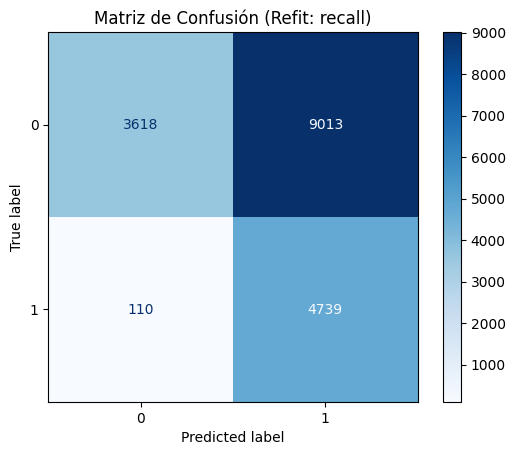

In [40]:
cm = confusion_matrix(y_test, y_predict)

# 3. Mostrarla de forma visual y bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_gs.classes_)
disp.plot(cmap='Blues')

plt.title('Matriz de Confusión (Refit: recall)')
plt.show()

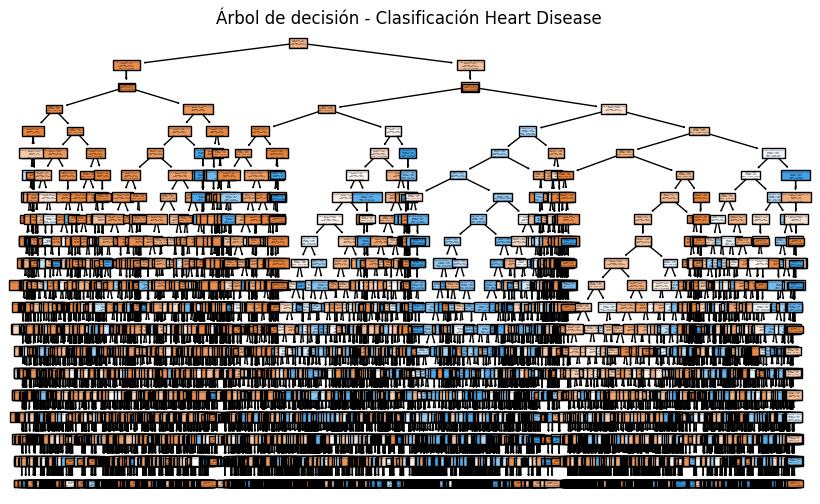

In [79]:
# Visualizamos el árbol
plt.figure(figsize=(10, 6))
plot_tree(best_model_dtc, feature_names=X.columns.to_list(), class_names={0: 'not_canceled', 1:'is_canceled'}, filled=True)
plt.title("Árbol de decisión - Clasificación Hotel Cancellation")
plt.show()